In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
import rdkit.Chem as Chem
def get_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: 
        return None
    Chem.Kekulize(mol)
    return mol

In [2]:
import pandas as pd

In [5]:
l = [1,2,3]

In [9]:
from pandas.core.frame import DataFrame
data=DataFrame(l, columns = ['smiles'])

In [1]:
import pandas as pd
raw = pd.read_csv('/mnt/disk1/xueying/tmp/antimalaria/antimalaria_v1.csv')
filtered = pd.read_csv('/mnt/disk1/xueying/tmp/antimalaria/malaria_format_CSP_rmDuplicates_labels.csv')

In [3]:
filtered.shape, len(filtered.CompoundID.unique())

((1698, 12), 1698)

In [4]:
m = filtered.merge(raw[['CompoundID', 'Label']])
m.shape

(1698, 13)

In [5]:
m.to_csv('/mnt/disk1/xueying/tmp/antimalaria/trainset_v1.csv', index=False)

In [7]:
import pandas as pd
# step1 输出
error = pd.read_csv('/mnt/disk1/xueying/tmp/antimalaria/trainset_v1_error.csv')
train = pd.read_csv('/mnt/disk1/xueying/tmp/antimalaria/trainset_v1.csv')
rm = train[~train['Cleaned_SMILES'].isin(error.smiles.values.tolist())]
rm.to_csv('/mnt/disk1/xueying/tmp/antimalaria/trainset_v2.csv', index=False)

In [8]:
rm

,Unnamed: 0,ID,CompoundID,SMILES,Cleaned_SMILES,ProjectCode,Value,Label_clf,Assay,Assay_Parameter,Operator,Units,Label
0,0,1,GDI-000912-001,CC1=CC=C(C=C1)C2(CC2)NC(=O)[C@H]3[C@@H](CNC3)C...,Cc1ccc(C2(NC(=O)C3CNCC3c3cc(F)c(C(F)(F)F)c(F)c...,GDI11,9.0,1,Activity,EC50,=,nM,8.045757
1,1,2,GDI-001022-001,CC1=CC=C(C=C1)C2(CC2)NC(=O)[C@H]3C(CNC3C)C4C=C...,Cc1ccc(C2(NC(=O)C3C(C)NCC3c3ccc(C(F)(F)F)c(Cl)...,GDI11,39.0,1,Activity,EC50,=,nM,7.408935
2,2,3,GDI-001276-001,CC1=CC=C(C=C1)C2(CC2)NC(=O)[C@H]3[C@H](CNC3=O)...,Cc1ccc(C2(NC(=O)C3C(=O)NCC3c3ccc(C(F)(F)F)c(Cl...,GDI11,50.0,1,Activity,EC50,=,nM,7.301030
3,3,4,GDI-001297-001,CC1=CC=C(C=C1)C2(NC(=O)[C@H]3C(CNC3)C4C=C(F)C(...,Cc1ccc(C2(NC(=O)C3CNCC3c3ccc(C(F)(F)F)c(F)c3)C...,GDI11,7.0,1,Activity,EC50,=,nM,8.154902
4,4,5,GDI-001298-001,CC1=CC=C(C=C1)C2(CC2)NC(=O)[C@H]3C(NC3)C4=CC=C...,Cc1ccc(C2(NC(=O)C3CNC3c3ccc(C(F)(F)F)cc3)CC2)cc1,GDI11,8331.0,0,Activity,EC50,=,nM,5.079303
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1693,1693,2307,GDI-006441-001,CC1=CC=C(C=C1)S(=O)(=O)CCNC(=O)C2C(=NOC=2C)C3=...,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3c(F)cccc3F)noc2...,GDI56,50000.0,0,Activity,EC50,=,nM,4.301030
1694,1694,2308,GDI-006442-001,CC1=CC=C(C=C1)S(=O)(=O)CCNC(=O)C2C(=NOC=2C)C3=...,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3ccccn3)noc2C)cc1,GDI56,50000.0,0,Activity,EC50,=,nM,4.301030
1695,1695,2309,GDI-006443-001,CC1=CC=C(C=C1)S(=O)(=O)CCNC(=O)C2C(=NOC=2C)C3=...,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3c(C)cccc3C)noc2...,GDI56,15655.4,0,Activity,EC50,=,nM,4.805336
1696,1696,2310,GDI-006444-001,CC1=CC=C(C=C1)S(=O)(=O)CCNC(=O)C2=C(N=CN2C)C3=...,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3c(Cl)cccc3Cl)nc...,GDI56,50000.0,0,Activity,EC50,=,nM,4.301030


In [10]:
v3 = rm[['CompoundID', 'Cleaned_SMILES', 'Operator', 'Value']]
v3.shape

(1681, 4)

In [11]:
v3.to_csv('/mnt/disk1/xueying/tmp/antimalaria/trainset_v3.csv', index=False)

In [40]:
import pandas as pd
from rdkit import Chem
nov = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/output/实验.csv')
nov['value'] = nov['EC50'].apply(lambda x: f'{(x):.2f}nM')
mol_list = []
for smi in nov['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    mol_list.append(mol)

In [41]:
nov

,ID,EC50,SMILES,生成个数,value
0,GDI-003399-001,1.0400,CNC(=O)C(Cc1ccc(-c2ccccc2O)cc1)n1c(=O)[nH]c2cc...,8,1.04nM
1,GDI-005843-001,1.1965,CC(C)(C)Nc1ccc2cc(-c3cnc(C(F)(F)F)nc3)c(O)c(CC...,8,1.20nM
2,GDI-005819-001,1.3840,CC(C)(C)Nc1ccc2cc(-c3cnc(C(F)(F)F)nc3)c(O)c(CC...,7,1.38nM
3,GDI-008234-001,1.4700,N#CC1(Nc2ccc(-c3c(F)cccc3CN)cc2)CC2(CCN(C(=O)N...,4,1.47nM
4,GDI-004626-001,1.5600,CC1CC(C)(C)N(C)c2c1cc(-c1cnc(C(F)(F)F)nc1)c(O)...,1,1.56nM


In [45]:
from rdkit.Chem import Draw
value_list = nov['value'].tolist()
img = Draw.MolsToGridImage(
    mol_list,
    molsPerRow=4,
    subImgSize=(200, 200),
    returnPNG=False,  # 返回图像对象而不是PNG数据
    legends=value_list,  # 使用SMILES字符串作为标注
    maxMols=4 #修改展示最大值
)
img.save('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/output/source.jpg', DPI=600)

/home/xueying/anaconda3/envs/jaeger/lib/python3.9/site-packages/rdkit/Chem/Draw/IPythonConsole.py:252: UserWarning: Truncating the list of molecules to be displayed to 4. Change the maxMols value to display more.
  warnings.warn(


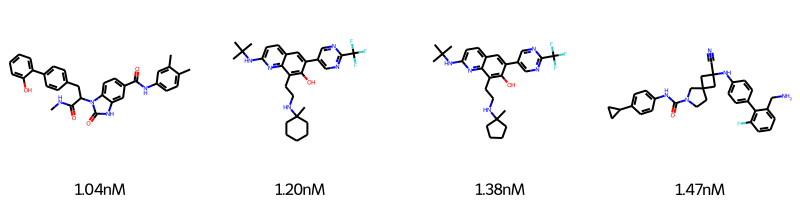

In [46]:
img